# Построение портфеля Марковица

**Цель проекта**: На основе данных мосбиржи сформировать 2 портфеля Марковица, один с минимальным риском и второй с заданной доходностью, под которую считается риск, также посчитать sharpe ratio для портфеля с заданной доходностью и найти оптимальный портфель с наибольшим sharpe ratio  

Для этого будем использовать python и библиотеки pandas, numpy и matplotlib для визуализации

# Получение данных

In [113]:
import pandas as pd
import numpy as np

In [114]:
data = pd.read_excel("/content/drive/MyDrive/mark_data.xlsx")

In [115]:
data.head()

,DATE,Т-технологии,Лукойл,Полюс,РоссетиМР,Сбер
0,2019-10-01,121.60,5919.5,680.00,0.9230,234.89
1,2019-11-01,118.58,6137.5,689.10,1.1130,233.98
2,2019-12-01,131.12,6169.0,710.35,1.1915,254.75
3,2020-01-01,151.50,6550.5,781.45,1.2490,252.20
4,2020-02-01,147.42,5699.5,846.40,1.0830,233.36


In [116]:
data.columns

Index(['DATE', 'Т-технологии', 'Лукойл', 'Полюс', 'РоссетиМР', 'Сбер'], dtype='object')

In [117]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   DATE          79 non-null     datetime64[ns]
 1   Т-технологии  79 non-null     float64       
 2   Лукойл        79 non-null     float64       
 3   Полюс         79 non-null     float64       
 4   РоссетиМР     79 non-null     float64       
 5   Сбер          79 non-null     float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 3.8 KB


 Таким образом у нас есть данные по стоимости акций в течении 79 месяцев

In [118]:
data = data.drop(columns = 'DATE')

# Математические вычисления

Посчитаем доходности


In [119]:
profit_data = (
    (data.iloc[1:, :].values - data.iloc[:-1, :].values) / data.iloc[:-1, :].values
)

profit_data = pd.DataFrame(profit_data, columns = data.columns)

In [120]:
profit_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Т-технологии  78 non-null     float64
 1   Лукойл        78 non-null     float64
 2   Полюс         78 non-null     float64
 3   РоссетиМР     78 non-null     float64
 4   Сбер          78 non-null     float64
dtypes: float64(5)
memory usage: 3.2 KB


Далее посчитаем выборочные средние для наших компаний

In [121]:
Sample_mean = profit_data.mean()
Sample_mean

,0
Т-технологии,0.022530
Лукойл,0.003237
Полюс,0.021479
РоссетиМР,0.013998
Сбер,0.009973


Далее необходимо посчитать матрицу ковариаций

In [122]:
Cov_matrix = profit_data.cov()
Cov_matrix

,Т-технологии,Лукойл,Полюс,РоссетиМР,Сбер
Т-технологии,0.018971,0.008326,0.004036,0.005177,0.008649
Лукойл,0.008326,0.008470,0.001419,0.003461,0.006036
Полюс,0.004036,0.001419,0.013846,0.001794,0.003181
РоссетиМР,0.005177,0.003461,0.001794,0.009783,0.004225
Сбер,0.008649,0.006036,0.003181,0.004225,0.010084


In [123]:
Cov_matrix = Cov_matrix * 12

In [124]:
Sample_mean = (1 + Sample_mean)**12 - 1
Sample_mean

,0
Т-технологии,0.306510
Лукойл,0.039549
Полюс,0.290484
РоссетиМР,0.181530
Сбер,0.126457


Далее найдем обратную матрицу

In [125]:
Inverse_matrix = np.linalg.inv(Cov_matrix)
Inverse_matrix

array([[ 9.05137457, -5.78306793, -1.10322822, -1.01763738, -3.5275474 ],
       [-5.78306793, 21.33006203,  1.44701141, -1.44388379, -7.65924378],
       [-1.10322822,  1.44701141,  6.66799785, -0.33847469, -1.88181627],
       [-1.01763738, -1.44388379, -0.33847469, 10.78472899, -2.67510079],
       [-3.5275474 , -7.65924378, -1.88181627, -2.67510079, 17.58930139]])

Далее найдем внешнее произведение выборочных средних

In [126]:
mean_matrix = np.outer(Sample_mean, Sample_mean)
mean_matrix

array([[0.09394847, 0.01212207, 0.08903617, 0.05564064, 0.0387604 ],
       [0.01212207, 0.0015641 , 0.01148824, 0.00717925, 0.00500121],
       [0.08903617, 0.01148824, 0.08438073, 0.05273135, 0.03673373],
       [0.05564064, 0.00717925, 0.05273135, 0.03295297, 0.02295571],
       [0.0387604 , 0.00500121, 0.03673373, 0.02295571, 0.01599141]])

Теперь необходимо посчитать величину альфа, бета и гамма

In [127]:
E = Sample_mean.values.reshape(-1, 1)
ones = np.ones((len(E), 1))

In [128]:
alpha = float(E.T @ Inverse_matrix @ E)
beta = float(E.T @ Inverse_matrix @ ones)
gamma = float(ones.T @ Inverse_matrix @ ones)
delta = alpha * gamma - beta**2
alpha, beta, gamma, delta

/tmp/ipykernel_2111/915888683.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  alpha = float(E.T @ Inverse_matrix @ E)
/tmp/ipykernel_2111/915888683.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  beta = float(E.T @ Inverse_matrix @ ones)
/tmp/ipykernel_2111/915888683.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma = float(ones.T @ Inverse_matrix @ ones)


(0.9988177605816105, 2.1716397953003828, 17.45748714193117, 12.720828811953663)

# Нахождение портфелей

Теперь готовы считать оба портфеля, начнем с портфеля с заданной доходностью


In [129]:
r = 0.20
n = len(E)
ones = np.ones((n, 1))
lam = (gamma * r - beta) / delta
mu = (alpha - beta * r) / delta
w = lam * (Inverse_matrix @ E) + mu * (Inverse_matrix @ ones)

In [130]:
weights = pd.DataFrame(
    w,
    index = Sample_mean.index,
    columns = ['Weight']
)

port_return_set = (E.T @ w)[0,0]
port_var_set = (w.T @ Cov_matrix.values @ w)[0,0]

print(weights)
print(f"Доходность портфеля равна {port_return_set}, а риск {port_var_set}")

                Weight
Т-технологии  0.059804
Лукойл        0.169694
Полюс         0.353379
РоссетиМР     0.355155
Сбер          0.061968
Доходность портфеля равна 0.19999999999999998, а риск 0.06512636404321437


Далее найдем портфель марковица с минимальной дисперсией

In [131]:
w_gvm = (Inverse_matrix @ ones) / gamma
port_return_min = (E.T @ w_gvm)[0, 0]
port_var_min = (w_gvm.T @ Cov_matrix.values @ w_gvm)[0, 0]
print(w_gvm)
print(f"Доходность портфеля равна {port_return_min}, а риск {port_var_min}")

[[-0.13633728]
 [ 0.45200537]
 [ 0.2744662 ]
 [ 0.30414643]
 [ 0.10571929]]
Доходность портфеля равна 0.12439589831255358, а риск 0.057282012690022165


# Визуализация эффективной границы Марковица

In [132]:
import numpy as np
import matplotlib.pyplot as plt

target_returns = np.linspace(0.05, 0.35, 100)

risks = []
returns = []

n = len(E)
ones = np.ones((n,1))

for r in target_returns:

    lam = (gamma * r - beta) / delta
    mu = (alpha - beta * r) / delta

    w = lam * (Inverse_matrix @ E) + mu * (Inverse_matrix @ ones)

    port_return = (E.T @ w)[0,0]

    port_var = (w.T @ Cov_matrix.values @ w)[0,0]

    port_risk = np.sqrt(port_var)

    returns.append(port_return)
    risks.append(port_risk)

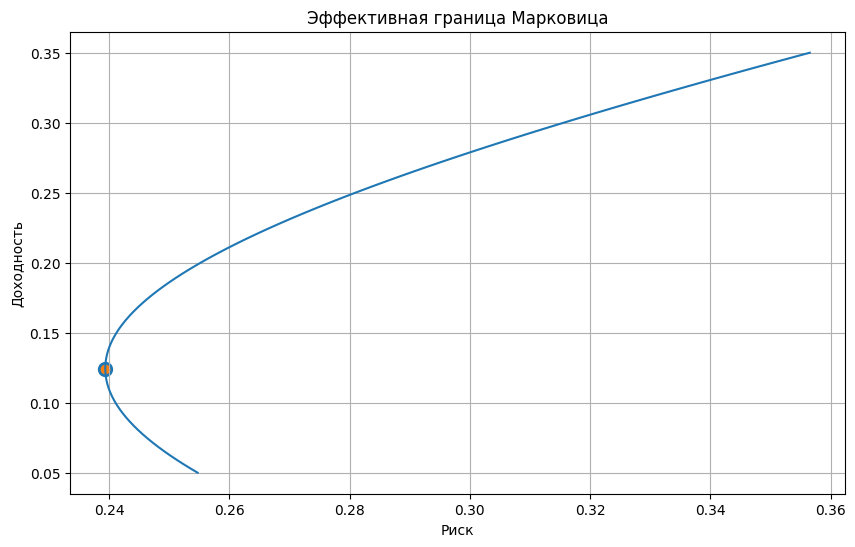

In [133]:
plt.figure(figsize=(10,6))

plt.plot(risks, returns)

plt.xlabel("Риск")
plt.ylabel("Доходность")
plt.title("Эффективная граница Марковица")

plt.grid(True)

gmv_return = (E.T @ w_gvm)[0,0]
gmv_var = (w_gvm.T @ Cov_matrix.values @ w_gvm)[0,0]
gmv_risk = np.sqrt(gmv_var)

plt.scatter(gmv_risk, gmv_return, s=100)
plt.scatter(gmv_risk, gmv_return, label='GMV Portfolio')

plt.show()

# Sharpe ratio

Теперь составим sharp ratio c безрисковой ставкой 3%, а также посчитаем годовую доходность

In [135]:
risk_free = 0.03
port_risk = np.sqrt(port_var_set)
sharpe_ratio = (port_return_set - risk_free) / port_risk
print(f"Portfolio return: {port_return_set:.2%}")
print(f"Portfolio risk: {port_risk:.2%}")
print(f"Sharpe ratio: {sharpe_ratio:.3f}")

Portfolio return: 20.00%
Portfolio risk: 25.52%
Sharpe ratio: 0.666


Теперь найдем портфель с наибольшим Sharpe ratio

In [136]:
ones = np.ones((len(E),1))

excess_returns = E - risk_free * ones
w_tangent = np.linalg.inv(Cov_matrix) @ excess_returns
w_tangent = w_tangent / w_tangent.sum()
tangent_return = (E.T @ w_tangent)[0,0]
tangent_var = (w_tangent.T @ Cov_matrix.values @ w_tangent)[0,0]

tangent_risk = np.sqrt(tangent_var)

tangent_sharpe = (
    (tangent_return - risk_free)
    / tangent_risk
)

print(f"Return: {tangent_return:.2%}")
print(f"Risk: {tangent_risk:.2%}")
print(f"Sharpe: {tangent_sharpe:.3f}")

Return: 56.66%
Risk: 57.06%
Sharpe: 0.940


In [139]:
weights = pd.DataFrame(
    w_tangent,
    index=Sample_mean.index,
    columns=["Weight"]
)

print(weights)

                Weight
Т-технологии  1.010819
Лукойл       -1.199127
Полюс         0.735999
РоссетиМР     0.602477
Сбер         -0.150168


# Итог

In [140]:
print("=" * 50)
print("PORTFOLIO OPTIMIZATION RESULTS")
print("=" * 50)

print(f"\nTangency Portfolio Return: {tangent_return:.2%}")
print(f"Tangency Portfolio Risk: {tangent_risk:.2%}")
print(f"Maximum Sharpe Ratio: {tangent_sharpe:.3f}")

print("\nPortfolio Weights:")
display(weights.round(4))

PORTFOLIO OPTIMIZATION RESULTS

Tangency Portfolio Return: 56.66%
Tangency Portfolio Risk: 57.06%
Maximum Sharpe Ratio: 0.940

Portfolio Weights:


,Weight
Т-технологии,1.0108
Лукойл,-1.1991
Полюс,0.7360
РоссетиМР,0.6025
Сбер,-0.1502


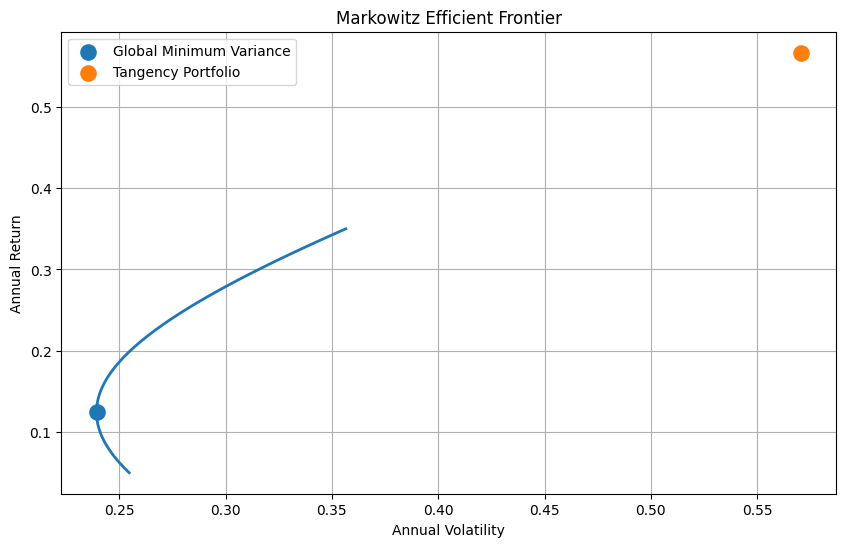

In [141]:
plt.figure(figsize=(10,6))

plt.plot(risks, returns, linewidth=2)

plt.scatter(
    gmv_risk,
    gmv_return,
    s=120,
    label='Global Minimum Variance'
)

plt.scatter(
    tangent_risk,
    tangent_return,
    s=120,
    label='Tangency Portfolio'
)

plt.xlabel("Annual Volatility")
plt.ylabel("Annual Return")
plt.title("Markowitz Efficient Frontier")

plt.legend()
plt.grid(True)

plt.show()